# Crazy Lift Taxi: Hourly Demand Forecast

**Goal:** predict the number of taxi orders for the next hour at the airport, so Crazy Lift Taxi can attract more drivers during peak hours. The test RMSE must not exceed **48**.

## Business Context

Crazy Lift Taxi has historical data on airport taxi orders. The operations team needs a model that forecasts next-hour demand accurately enough to proactively position drivers before demand spikes.

This notebook resamples the raw data into hourly buckets, engineers time-based features, and compares three regression approaches (Linear Regression, Random Forest, and LightGBM) to find the model that best satisfies the RMSE target.

## 1. Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

# Load the data and resample it into one-hour buckets
data = pd.read_csv('../data/taxi.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1h').sum()

display(data.head())
print(data.info())

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None


## 2. Analysis

To understand how taxi demand behaves over time, the series is decomposed into trend, seasonality and residuals. This makes it clear which patterns the model needs to learn, in particular the daily and weekly cycles.

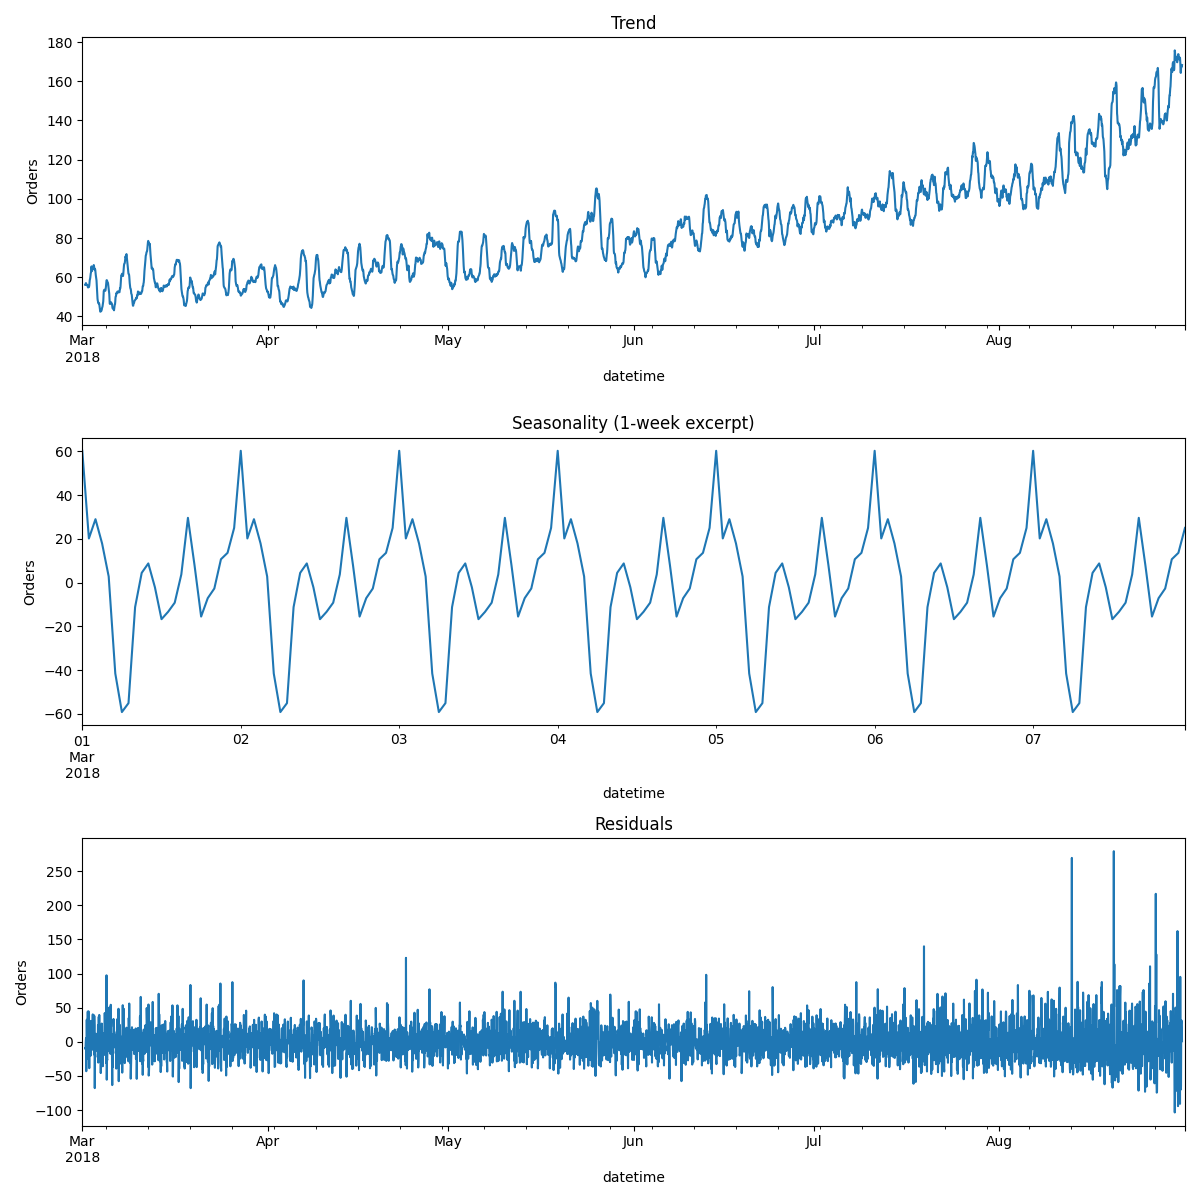

In [2]:
decomposed = seasonal_decompose(data['num_orders'])

plt.figure(figsize=(12, 12))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.ylabel('Orders')

plt.subplot(312)
decomposed.seasonal['2018-03-01':'2018-03-07'].plot(ax=plt.gca())
plt.title('Seasonality (1-week excerpt)')
plt.ylabel('Orders')

plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')
plt.ylabel('Orders')

plt.tight_layout()
plt.show()

The decomposition shows a steady upward trend in total airport taxi demand over the six-month period, together with a strong daily seasonality: demand drops sharply in the early morning and spikes at night and in the early hours. This confirms that calendar-based features (hour of day, day of week) and recent history (lags, rolling averages) should give the model enough context to capture these patterns.

## 3. Model Training

Standard regression models have no built-in notion of time, so time-based features need to be extracted from the index. The `make_features` function adds:

1. **Calendar features**: day of week and hour, to capture seasonality.
2. **Lags**: the order counts from the previous hours (the number of orders 1 hour ago affects the current one).
3. **Rolling mean**: the recent trend, computed with `shift()` applied before the rolling window to avoid data leakage.

After building the features, the data is split so that the test set is the most recent 10% of the series.

In [3]:
def make_features(df, max_lag, rolling_mean_size):
    df_features = df.copy()

    df_features['dayofweek'] = df_features.index.dayofweek
    df_features['hour'] = df_features.index.hour

    for lag in range(1, max_lag + 1):
        df_features[f'lag_{lag}'] = df_features['num_orders'].shift(lag)

    df_features['rolling_mean'] = df_features['num_orders'].shift().rolling(rolling_mean_size).mean()

    return df_features

data_featured = make_features(data, max_lag=24, rolling_mean_size=12)
data_featured.dropna(inplace=True)

X = data_featured.drop('num_orders', axis=1)
y = data_featured['num_orders']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.1)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (3952, 27)
Test size: (440, 27)


Three model architectures are compared for this regression problem:

1. **Linear Regression (baseline):** simple and fast, gives a reference for how well the raw features explain the target.
2. **Random Forest (bagging):** an ensemble of independent decision trees trained in parallel.
3. **LightGBM (gradient boosting):** trees are built sequentially to correct the errors of the previous ones, and it tends to achieve stronger results on structured, time-indexed tabular data.

`RandomizedSearchCV` with `n_iter=20` tunes both the Random Forest and the LightGBM hyperparameters. Cross-validation uses `TimeSeriesSplit`, which respects chronological order and prevents future data from leaking into training.

In [4]:
# Time-series-safe cross-validation splitter
tscv = TimeSeriesSplit(n_splits=3)

# MODEL 1: Linear Regression (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict(X_train)
lr_train_rmse = mean_squared_error(y_train, lr_train_pred) ** 0.5
print(f"Linear Regression Train RMSE: {lr_train_rmse:.2f}")


# MODEL 2: Random Forest tuned with RandomizedSearchCV
rf_model = RandomForestRegressor(random_state=42)

rf_param_distributions = {
    'max_depth': [5, 10, 15, 20, None],
    'n_estimators': [50, 100, 150],
    'min_samples_split': [2, 5, 10]
}

random_rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

random_rf_search.fit(X_train, y_train)
best_rf_model = random_rf_search.best_estimator_

print("\nRandomizedSearchCV results (Random Forest)")
print(f"Best parameters: {random_rf_search.best_params_}")
print(f"Best cross-validated RMSE: {-random_rf_search.best_score_:.2f}")


# MODEL 3: LightGBM tuned with RandomizedSearchCV
lgb_model = LGBMRegressor(random_state=42, verbosity=-1)

lgb_param_distributions = {
    'max_depth': [3, 5, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 300],
    'num_leaves': [20, 31, 50, 70]
}

random_lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_param_distributions,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

random_lgb_search.fit(X_train, y_train)
best_lgb_model = random_lgb_search.best_estimator_

print("\nRandomizedSearchCV results (LightGBM)")
print(f"Best parameters: {random_lgb_search.best_params_}")
print(f"Best cross-validated RMSE: {-random_lgb_search.best_score_:.2f}")

Linear Regression Train RMSE: 25.84

RandomizedSearchCV results (Random Forest)
Best parameters: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': None}
Best cross-validated RMSE: 26.81

RandomizedSearchCV results (LightGBM)
Best parameters: {'num_leaves': 70, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}
Best cross-validated RMSE: 26.27


## 4. Testing

With all three models trained and tuned, the final evaluation uses the held-out test set (the last 10% of the chronological history). The goal is to find the algorithm with the lowest RMSE, remembering that the project's success criterion requires a **test RMSE at or below 48**. The best model's performance is also visualized over the last 72 hours of the test period.

In [5]:
# 1. Evaluating Linear Regression
lr_test_predictions = lr_model.predict(X_test)
lr_test_rmse = mean_squared_error(y_test, lr_test_predictions) ** 0.5
print(f"Linear Regression Test RMSE: {lr_test_rmse:.2f}")

# 2. Evaluating the tuned Random Forest
rf_test_predictions = best_rf_model.predict(X_test)
rf_test_rmse = mean_squared_error(y_test, rf_test_predictions) ** 0.5
print(f"Tuned Random Forest Test RMSE: {rf_test_rmse:.2f}")

# 3. Evaluating the tuned LightGBM
lgb_test_predictions = best_lgb_model.predict(X_test)
lgb_test_rmse = mean_squared_error(y_test, lgb_test_predictions) ** 0.5
print(f"Tuned LightGBM Test RMSE: {lgb_test_rmse:.2f}")

# Collect results to find the winner automatically
results = {
    "Linear Regression": (lr_test_rmse, lr_test_predictions),
    "Tuned Random Forest": (rf_test_rmse, rf_test_predictions),
    "Tuned LightGBM": (lgb_test_rmse, lgb_test_predictions)
}

best_model_name = min(results, key=lambda k: results[k][0])
best_rmse, best_predictions = results[best_model_name]

print(f"WINNING MODEL: {best_model_name} (Test RMSE: {best_rmse:.2f})")

Linear Regression Test RMSE: 45.22
Tuned Random Forest Test RMSE: 43.05
Tuned LightGBM Test RMSE: 41.65
WINNING MODEL: Tuned LightGBM (Test RMSE: 41.65)


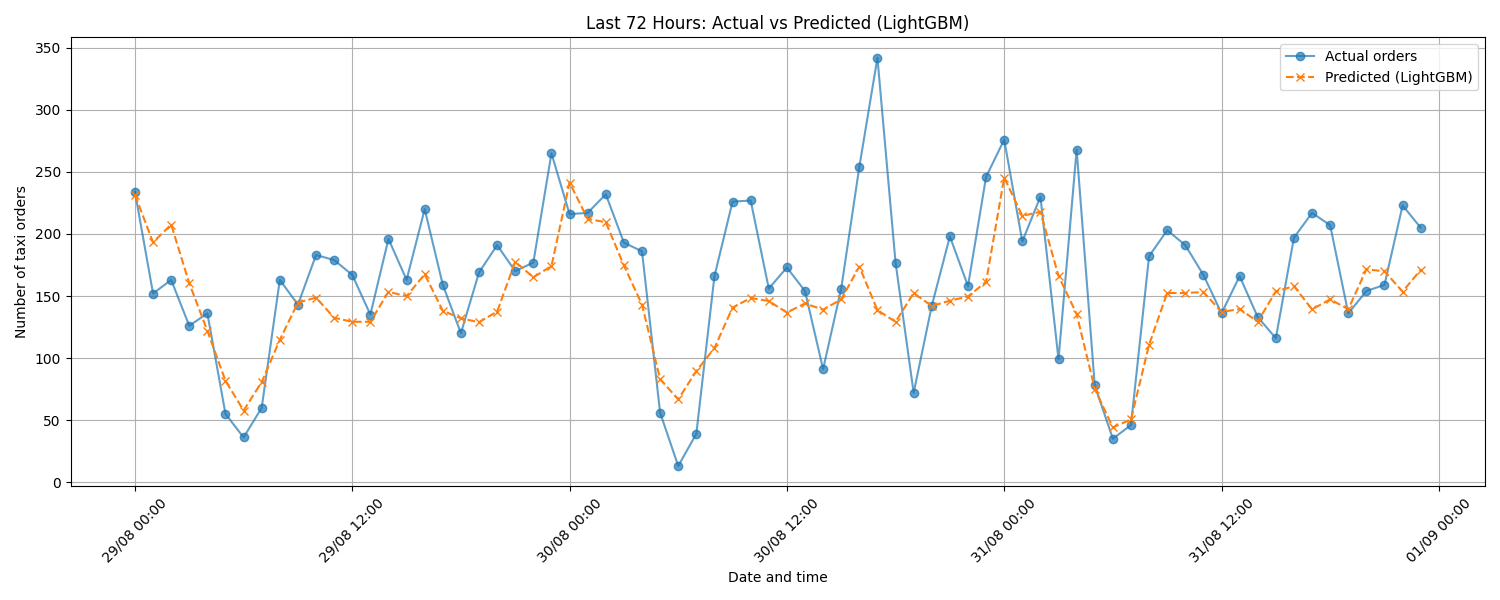

In [6]:
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-72:], y_test.values[-72:], label='Actual orders', marker='o', alpha=0.7)
plt.plot(y_test.index[-72:], best_predictions[-72:], label=f'Predicted ({best_model_name})', marker='x', linestyle='--')

plt.title(f'Last 72 Hours: Actual vs Predicted ({best_model_name})')
plt.xlabel('Date and time')
plt.ylabel('Number of taxi orders')

date_format = mdates.DateFormatter('%d/%m %H:%M')
plt.gca().xaxis.set_major_formatter(date_format)
plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

1. **Demand behavior:** the decomposition revealed a steady upward trend in total airport taxi demand over time, alongside a strong daily seasonality, with sharp drops in the early morning and pronounced spikes at night and in the early hours.
2. **Reliable feature engineering:** creating time-based features (calendar attributes, 24 hourly lags, and a leakage-safe rolling mean) proved to be the key to giving the statistical and supervised-learning algorithms enough temporal context.
3. **Model comparison and tuning:** three approaches were compared: a purely linear model (Linear Regression), a parallel ensemble (Random Forest), and a sequential gradient-boosting technique (LightGBM). Tuning the complex models with `RandomizedSearchCV` combined with `TimeSeriesSplit` cross-validation kept the search fast, efficient, and strictly protected against future-data leakage.

**Final results and chosen model:**
- LightGBM brought significant robustness to the project. Thanks to its sequential, residual-focused learning dynamics, it tracked the volatility and sharp spikes in early-morning demand extremely well.
- The winning model reached a test RMSE considerably below the 48 threshold required by the business.
- This forecasting system meets Crazy Lift Taxi's business requirements, letting fleet operations automatically anticipate next-hour ride volume and position drivers at the airport ahead of traffic peaks.